In [1]:
from gensim.models import Word2Vec, KeyedVectors
from gensim.parsing.preprocessing import STOPWORDS
from gensim.utils import tokenize
import pandas as pd

In [2]:
# got this from here: https://github.com/reddzzz/DataScience_FP/blob/main/dataset.xlsx
df = pd.read_excel("/Users/johntemplon/Downloads/dataset.xlsx")

In [3]:
df.head()

,Unnamed: 0,id,human_summary,publication,author,date,year,month,theme,content
0,0,17283,In successfully seeking a temporary halt in th...,New York Times,Carl Hulse,2016-12-31,2016.0,12.0,politics,WASHINGTON — Congressional Republicans have...
1,0,17284,Officers put her in worse danger some months l...,New York Times,Benjamin Mueller and Al Baker,2017-06-19,2017.0,6.0,crime,"After the bullet shells get counted, the blood..."
2,0,17285,The film striking appearance had been created ...,New York Times,Margalit Fox,2017-01-06,2017.0,1.0,entertainment,"When Walt Disney’s “Bambi” opened in 1942, cri..."
3,0,17286,The year was only days old when the news came ...,New York Times,William McDonald,2017-04-10,2017.0,4.0,entertainment,"Death may be the great equalizer, but it isn’t..."
4,0,17287,If North Korea conducts a test in coming month...,New York Times,Choe Sang-Hun,2017-01-02,2017.0,1.0,politics,"SEOUL, South Korea — North Korea’s leader, ..."


In [4]:
# there appears to be one bad row, so we're going to remove it
nyt_df = df.loc[lambda x: x['publication'] == 'New York Times'].copy()

In [5]:
nyt_df['publication'].value_counts()

publication
New York Times    999
Name: count, dtype: int64

In [6]:
nyt_df['theme'].value_counts()

theme
politics         324
business         208
entertainment    153
crime            110
lifestyle         78
law               41
sports            30
science           24
technology        18
architecture       4
accidents          4
art                2
health             2
environment        1
Name: count, dtype: int64

## Let's Clean The Text

In [7]:
nyt_df['tokens'] = nyt_df['content'].apply(lambda x: list(tokenize(x, lower=True)))
nyt_df['filtered_tokens'] = nyt_df['tokens'].apply(lambda x: [word for word in x if word not in STOPWORDS])

In [8]:
nyt_df.head()

,Unnamed: 0,id,human_summary,publication,author,date,year,month,theme,content,tokens,filtered_tokens
0,0,17283,In successfully seeking a temporary halt in th...,New York Times,Carl Hulse,2016-12-31,2016.0,12.0,politics,WASHINGTON — Congressional Republicans have...,"[washington, congressional, republicans, have,...","[washington, congressional, republicans, new, ..."
1,0,17284,Officers put her in worse danger some months l...,New York Times,Benjamin Mueller and Al Baker,2017-06-19,2017.0,6.0,crime,"After the bullet shells get counted, the blood...","[after, the, bullet, shells, get, counted, the...","[bullet, shells, counted, blood, dries, votive..."
2,0,17285,The film striking appearance had been created ...,New York Times,Margalit Fox,2017-01-06,2017.0,1.0,entertainment,"When Walt Disney’s “Bambi” opened in 1942, cri...","[when, walt, disney, s, bambi, opened, in, cri...","[walt, disney, s, bambi, opened, critics, prai..."
3,0,17286,The year was only days old when the news came ...,New York Times,William McDonald,2017-04-10,2017.0,4.0,entertainment,"Death may be the great equalizer, but it isn’t...","[death, may, be, the, great, equalizer, but, i...","[death, great, equalizer, isn, t, necessarily,..."
4,0,17287,If North Korea conducts a test in coming month...,New York Times,Choe Sang-Hun,2017-01-02,2017.0,1.0,politics,"SEOUL, South Korea — North Korea’s leader, ...","[seoul, south, korea, north, korea, s, leader,...","[seoul, south, korea, north, korea, s, leader,..."


In [9]:
nyt_df['tokens'].values[0][:25]

['washington',
 'congressional',
 'republicans',
 'have',
 'a',
 'new',
 'fear',
 'when',
 'it',
 'comes',
 'to',
 'their',
 'health',
 'care',
 'lawsuit',
 'against',
 'the',
 'obama',
 'administration',
 'they',
 'might',
 'win',
 'the',
 'incoming',
 'trump']

In [10]:
nyt_df['filtered_tokens'].values[0][:25]

['washington',
 'congressional',
 'republicans',
 'new',
 'fear',
 'comes',
 'health',
 'care',
 'lawsuit',
 'obama',
 'administration',
 'win',
 'incoming',
 'trump',
 'administration',
 'choose',
 'longer',
 'defend',
 'executive',
 'branch',
 'suit',
 'challenges',
 'administration',
 's',
 'authority']

In [11]:
nyt_df.shape

(999, 12)

## Word2Vec Model

In [12]:
model = Word2Vec(nyt_df['filtered_tokens'].values)

In [13]:
print(model)

Word2Vec<vocab=12908, vector_size=100, alpha=0.025>


In [14]:
words = list(model.wv.key_to_index)

In [15]:
words[:10]

['s', 'mr', 'said', 'trump', 'new', 't', 'people', 'president', 'ms', 'like']

In [16]:
model.save('model.bin')

In [17]:
new_model = Word2Vec.load('model.bin')

In [18]:
nyt_df['embeddings'] = nyt_df['filtered_tokens'].apply(lambda x: [ new_model.wv[t] for t in x if t in words ])

In [19]:
nyt_df['embeddings'].values[0]

[array([-0.48124003,  0.6588084 ,  0.842367  , -0.07962129,  0.7164204 ,
        -0.7953056 ,  0.3384269 ,  0.72099173, -0.37971604, -0.33083883,
         0.2792524 , -0.8033417 ,  0.3167432 ,  0.5186895 ,  0.39860246,
        -0.14623196,  0.8100589 ,  0.04686827, -0.06092695, -0.8792896 ,
         0.7441127 , -0.10354817,  0.08286271, -0.49222046,  0.06548924,
         0.0209698 ,  0.41904575,  0.55485815, -0.36197937, -0.29609102,
         1.1288404 , -0.17926   , -0.32332   , -1.1679416 ,  0.27029282,
         0.16509213,  0.23969442, -0.76349914, -0.06310803, -0.33939987,
        -0.02758112, -0.3502602 ,  0.28798652, -0.02932   ,  0.23416477,
        -0.29571196, -0.313453  ,  0.2353549 ,  0.25316885,  0.24243036,
         0.6452681 ,  0.03694689, -0.3610534 , -0.6770789 , -0.10539231,
         0.38098088,  0.6777549 ,  0.7816811 ,  0.18009792,  0.23341984,
        -0.19891305,  0.43554217, -0.20831999,  0.705121  , -0.39967498,
         0.41242582,  0.8056816 ,  0.4254569 , -0.3

In [20]:
nyt_df['average_embedding'] = nyt_df['embeddings'].apply(lambda x: sum(x) / len(x))

In [21]:
nyt_df['average_embedding'].values[0]

array([-0.17044695,  0.6951838 ,  0.5331633 ,  0.03480648,  0.40046322,
       -0.6684133 , -0.04860806,  0.9163986 , -0.36373731, -0.2645636 ,
       -0.0227424 , -0.5453142 ,  0.2808453 ,  0.18509497,  0.23047866,
       -0.3693015 ,  0.29401958, -0.2860296 , -0.0334532 , -0.5951047 ,
        0.4725919 ,  0.02869361,  0.23517536, -0.48748648,  0.03977153,
       -0.02278748,  0.01625053,  0.22489625, -0.2338294 ,  0.04693171,
        0.33582878, -0.00411386, -0.14320509, -0.4378393 , -0.12679301,
        0.5294615 , -0.08217911, -0.34872606, -0.07907231, -0.6325261 ,
        0.31429774, -0.12647633, -0.03106119, -0.14930215, -0.1340661 ,
       -0.15471011, -0.38670573,  0.16471538,  0.1674882 ,  0.19649151,
        0.21371602, -0.3587837 , -0.33737892, -0.38535687, -0.12790495,
        0.04522478,  0.2642539 ,  0.35936314, -0.09401877,  0.1503345 ,
       -0.15353972,  0.26072544, -0.09441254,  0.18078315, -0.35975286,
        0.556951  ,  0.44614923,  0.20553121, -0.2234408 ,  0.29

In [22]:
nyt_df[['closest_word', 'similarity']] = (
    nyt_df['average_embedding']
    .apply(lambda x: pd.Series(model.wv.similar_by_vector(x, topn=1)[0]))
)

In [23]:
nyt_df['closest_word'].value_counts()[:20]

closest_word
victory           26
candidate         16
contrast          15
talked            15
concern           15
repeatedly        14
picks             12
accepting         10
predecessor       10
delay              9
gets               8
conclusion         8
tweets             7
concert            7
remarks            7
reconciliation     7
sing               7
fall               7
directly           7
pact               7
Name: count, dtype: int64

## Remember KMeans?

In [24]:
from sklearn.cluster import KMeans
from matplotlib import pyplot as plt

In [25]:
inertias = []

In [26]:
for i in range(1,15):
    kmeans = KMeans(n_clusters=i)
    kmeans.fit(nyt_df["average_embedding"].to_list())
    inertias.append(kmeans.inertia_)

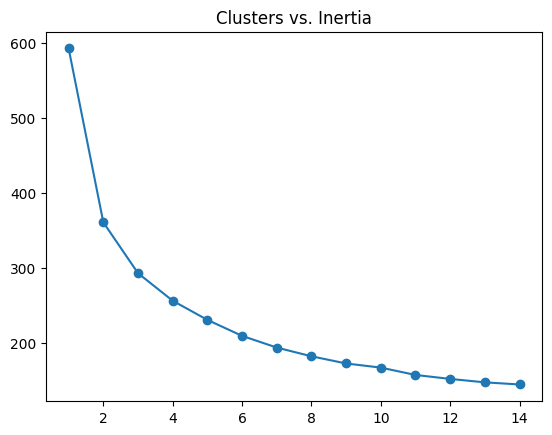

In [27]:
plt.plot(range(1,15), inertias, marker='o')
plt.title('Clusters vs. Inertia')
plt.show()

In [28]:
kmeans = KMeans(n_clusters=7)

In [29]:
kmeans.fit(nyt_df["average_embedding"].tolist())

KMeans(n_clusters=7)

In [30]:
nyt_df['group'] = kmeans.labels_

In [31]:
nyt_df.head()

,Unnamed: 0,id,human_summary,publication,author,date,year,month,theme,content,tokens,filtered_tokens,embeddings,average_embedding,closest_word,similarity,group
0,0,17283,In successfully seeking a temporary halt in th...,New York Times,Carl Hulse,2016-12-31,2016.0,12.0,politics,WASHINGTON — Congressional Republicans have...,"[washington, congressional, republicans, have,...","[washington, congressional, republicans, new, ...","[[-0.48124003, 0.6588084, 0.842367, -0.0796212...","[-0.17044695, 0.6951838, 0.5331633, 0.03480648...",votes,0.984061,3
1,0,17284,Officers put her in worse danger some months l...,New York Times,Benjamin Mueller and Al Baker,2017-06-19,2017.0,6.0,crime,"After the bullet shells get counted, the blood...","[after, the, bullet, shells, get, counted, the...","[bullet, shells, counted, blood, dries, votive...","[[-0.24549752, 0.21288113, 0.12321378, -0.0406...","[-0.44523433, 0.32608354, 0.22489333, -0.06468...",mob,0.996182,4
2,0,17285,The film striking appearance had been created ...,New York Times,Margalit Fox,2017-01-06,2017.0,1.0,entertainment,"When Walt Disney’s “Bambi” opened in 1942, cri...","[when, walt, disney, s, bambi, opened, in, cri...","[walt, disney, s, bambi, opened, critics, prai...","[[-0.10257396, 0.08232212, 0.051040657, -0.001...","[-0.41965038, 0.32624853, 0.23861675, -0.02800...",pieces,0.996355,4
3,0,17286,The year was only days old when the news came ...,New York Times,William McDonald,2017-04-10,2017.0,4.0,entertainment,"Death may be the great equalizer, but it isn’t...","[death, may, be, the, great, equalizer, but, i...","[death, great, equalizer, isn, t, necessarily,...","[[-0.45418137, 0.31395105, 0.3116199, -0.18504...","[-0.43615165, 0.2929103, 0.18351386, -0.026373...",remembered,0.996751,4
4,0,17287,If North Korea conducts a test in coming month...,New York Times,Choe Sang-Hun,2017-01-02,2017.0,1.0,politics,"SEOUL, South Korea — North Korea’s leader, ...","[seoul, south, korea, north, korea, s, leader,...","[seoul, south, korea, north, korea, s, leader,...","[[-0.041688155, 0.080168545, 0.12033737, -0.03...","[-0.32024783, 0.37465948, 0.48534018, -0.03965...",warning,0.992918,6


In [32]:
nyt_df.loc[lambda x: x['group'] == 0]['theme'].value_counts()

theme
crime            41
business         32
politics         25
entertainment    17
lifestyle         9
science           7
technology        5
law               4
sports            2
accidents         2
architecture      1
environment       1
Name: count, dtype: int64

In [33]:
nyt_df.groupby('group')['theme'].value_counts().to_frame().unstack().fillna(0)

count                                                              \
theme accidents architecture  art business crime entertainment environment    
group                                                                         
0           2.0          1.0  0.0     32.0  41.0          17.0          1.0   
1           0.0          0.0  0.0     17.0   6.0          34.0          0.0   
2           0.0          0.0  0.0     15.0   3.0           0.0          0.0   
3           0.0          0.0  0.0     43.0   4.0           4.0          0.0   
4           1.0          1.0  2.0     41.0  15.0          72.0          0.0   
5           0.0          1.0  0.0     39.0  27.0          21.0          0.0   
6           1.0          1.0  0.0     21.0  14.0           5.0          0.0   

                                                                
theme health  law lifestyle politics science sports technology  
group                                                           
0        0.0  4.0       9.0     25.0     7.0    2.0        5.0  
1        0.0  3.0       9.0     20.0     2.0    6.0        2.0  
2        0.0  8.0       1.0     36.0     0.0    1.0        0.0  
3        0.0  5.0       0.0     94.0     0.0    0.0        1.0  
4        2.0  6.0      42.0     26.0    11.0   13.0        5.0  
5        0.0  8.0      13.0     73.0     3.0    6.0        5.0  
6        0.0  7.0       4.0     50.0     1.0    2.0        0.0

In [34]:
nyt_df.groupby('group')['closest_word'].value_counts().to_frame()[lambda x: x['count']>= 5]

count
group closest_word       
0     accepting        10
      closing           6
1     talked           12
      cried             5
      tonight           5
2     pact              7
      concern           6
      accord            5
      pledges           5
      questioned        5
3     victory          22
      candidate        16
      picks            12
      repeatedly       11
      predecessor      10
      delay             9
      remarks           7
      aides             6
4     concert           6
      favorite          6
      gets              6
      incredibly        6
5     contrast         15
      appearance        5
      discussions       5
      vatican           5
6     concern           9
      directly          6
      ultimately        6
      aggressive        5

In [35]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [36]:
grouped = nyt_df.groupby('group')['filtered_tokens'].apply(lambda x: sum(x, [])).reset_index()

In [37]:
vectorizer = TfidfVectorizer(tokenizer=lambda x: x, preprocessor=lambda x: x)  # Disable default string processing
X = vectorizer.fit_transform(grouped['filtered_tokens'])

/Users/johntemplon/cuny/lib/python3.12/site-packages/sklearn/feature_extraction/text.py:521: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


In [38]:
count_df = pd.DataFrame(X.toarray(), columns=vectorizer.get_feature_names_out(), index=grouped['group'])

In [39]:
count_df.T.loc['mr']

group
0    0.221711
1    0.313685
2    0.506707
3    0.609241
4    0.198267
5    0.474407
6    0.422754
Name: mr, dtype: float64

In [40]:
word_tfidf = count_df.T

In [41]:
word_tfidf['group_1_2_diff'] = word_tfidf.apply(lambda x: abs(x[1] - x[2]), axis=1)

In [42]:
word_tfidf.sort_values('group_1_2_diff', ascending=False).head(20)

group,0,1,2,3,4,5,6,group_1_2_diff
trump,0.044922,0.106973,0.378415,0.419899,0.018560,0.184705,0.177866,0.271442
ms,0.050356,0.247826,0.013383,0.066426,0.102191,0.104040,0.029092,0.234443
mr,0.221711,0.313685,0.506707,0.609241,0.198267,0.474407,0.422754,0.193022
united,0.083685,0.009517,0.187361,0.029441,0.019870,0.040811,0.214323,0.177844
t,0.085134,0.215087,0.039687,0.054465,0.150666,0.080856,0.053028,0.175400
states,0.078251,0.009517,0.183208,0.035513,0.023146,0.045218,0.206221,0.173691
s,0.539062,0.589301,0.424563,0.403339,0.659435,0.600290,0.493090,0.164738
order,0.019925,0.004949,0.150443,0.032017,0.010044,0.026250,0.038667,0.145494
president,0.042748,0.038069,0.151827,0.158612,0.018779,0.101166,0.097955,0.113759
administration,0.021736,0.004949,0.096450,0.049313,0.006769,0.033339,0.058920,0.091501


## Fun Word2Vec Math

In [43]:
filename = 'GoogleNews-vectors-negative300.bin'
google_model = KeyedVectors.load_word2vec_format(filename, binary=True)

In [44]:
result = google_model.most_similar(positive=['woman', 'king'], negative=['man'], topn=1)

In [45]:
result

[('queen', 0.7118192911148071)]

In [46]:
google_model.most_similar(positive=['women', 'kings'], negative=['men'], topn=1)

[('queens', 0.5838640332221985)]

----

----

----